# Larsen C AWS data and RACMO (2km downscaled version)

Comparisons between AWS data and RACMO at our field site on Flask Glacier and at a site on the Larsen C Ice Shelf. 

Data from AWS18 on the Larsen C Ice Shelf comes from https://doi.pangaea.de/10.1594/PANGAEA.974128

Two other time series of temperature some from AWS20 (nearby) and were supplied to us in personal communication with Maurice van Tiggelen (m.vantiggelen@uu.nl).
These are the data in AWS20_temp.csv and AWS20_temp_2025.csv

Unlike code/aws/larsen_AWS_fieldseason.ipynb this NB loads the 2km downscaled version of RACMO (see code/rcm/racmo_2km_daily_1979-2025.ipynb).

In [46]:
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr
import geopandas as gpd
import hvplot.xarray
import matplotlib.pyplot as plt

In [2]:
FG_AWS = xr.load_dataset('aws_season_1.nc')  # created with code/aws/season_1.ipynb
FG_AWS

<xarray.Dataset> Size: 150kB
Dimensions:           (time: 335)
Coordinates:
    index             (time) int64 3kB 0 1 2 3 4 5 6 ... 329 330 331 332 333 334
  * time              (time) datetime64[ns] 3kB 2024-12-02T10:59:59.971000 .....
Data variables: (12/54)
    RECORD            (time) float64 3kB 6.0 7.0 8.0 9.0 ... 338.0 339.0 340.0
    TempVue20T_C_Avg  (time) float64 3kB -5.659 -6.46 -7.209 ... -4.144 -4.044
    TempVue20T_C_Max  (time) float64 3kB -5.26 -5.13 -6.92 ... -3.49 -3.79 -3.8
    TempVue20T_C_Min  (time) float64 3kB -5.99 -7.25 -7.39 ... -4.14 -4.49 -4.39
    AirTmpC_Avg       (time) float64 3kB -6.217 -6.929 -7.238 ... -4.166 -4.072
    AirTmpC_Max       (time) float64 3kB -6.031 -6.269 -7.1 ... -3.908 -3.866
    ...                ...
    GKN_9m_TmpC       (time) float64 3kB 7.915 9.23 9.59 ... -127.9 -127.9
    GKN_9_2m_TmpC     (time) float64 3kB 9.8 17.45 18.2 ... -127.9 -127.9 -127.9
    GKN_9_4m_TmpC     (time) float64 3kB 8.75 12.52 12.41 ... -127.9 -127.8
    GKN_9_6m_TmpC     (time) float64 3kB 8.53 13.71 14.9 ... -127.9 -127.9
    GKN_9_8m_TmpC     (time) float64 3kB 6.998 14.52 14.79 ... -127.9 -127.8
    GKN_10m_TmpC      (time) float64 3kB 6.675 12.85 12.91 ... -127.9 -127.8

## Load AWS18 data

In [3]:
fname = "../../data/flask/aws/AWS18/IMAU_ANT_AWS18.tab"

with open(fname) as f:
    lines = f.readlines()
# Find the first line that contains */
cut_line = next(i for i, line in enumerate(lines) if "*/" in line)
aws18_df = pd.read_csv("../../data/flask/aws/AWS18/IMAU_ANT_AWS18.tab", skiprows=cut_line+1, delimiter='\t', parse_dates=["Date/Time"] )  
# aws20_ds1 = aws18_df.set_index("Date/Time").to_xarray()
# aws20_ds1#['TTT [°C]']

## Load AWS20 data

In [ ]:
# load csvs into pandas dataframes
aws20_df1 = pd.read_csv("../../data/flask/aws/AWS20/AWS20_temp.csv", parse_dates=["datetime"] )  
aws20_df2 = pd.read_csv("../../data/flask/aws/AWS20/AWS20_temp_2025.csv", parse_dates=["datetime"] ) #This is using a slightly different sensor and has a little more recent data. Not significantly for this analysis though. 


## Combine all three AWS T time series 

In [16]:
# rename temperature columns
aws18_df = aws18_df.rename(columns={"TTT [°C]": "temperature"})
aws20_df1 = aws20_df1.rename(columns={"t": "temperature"})
aws20_df2 = aws20_df2.rename(columns={"Thut": "temperature"})

# rename datetime columns
aws18_df = aws18_df.rename(columns={"Date/Time": "datetime"})

# extract temperature data and convert to xarray datasets
def extract_temperature_ds(df): return df.set_index("datetime").to_xarray().temperature
aws18_ds = extract_temperature_ds(aws18_df)
aws20_ds1 = extract_temperature_ds(aws20_df1)
aws20_ds2 = extract_temperature_ds(aws20_df2)


aws20_ds2 = aws20_ds2.where(aws20_ds2 < 20)

AWS_LC = xr.merge([aws18_ds, aws20_ds1], compat="override")

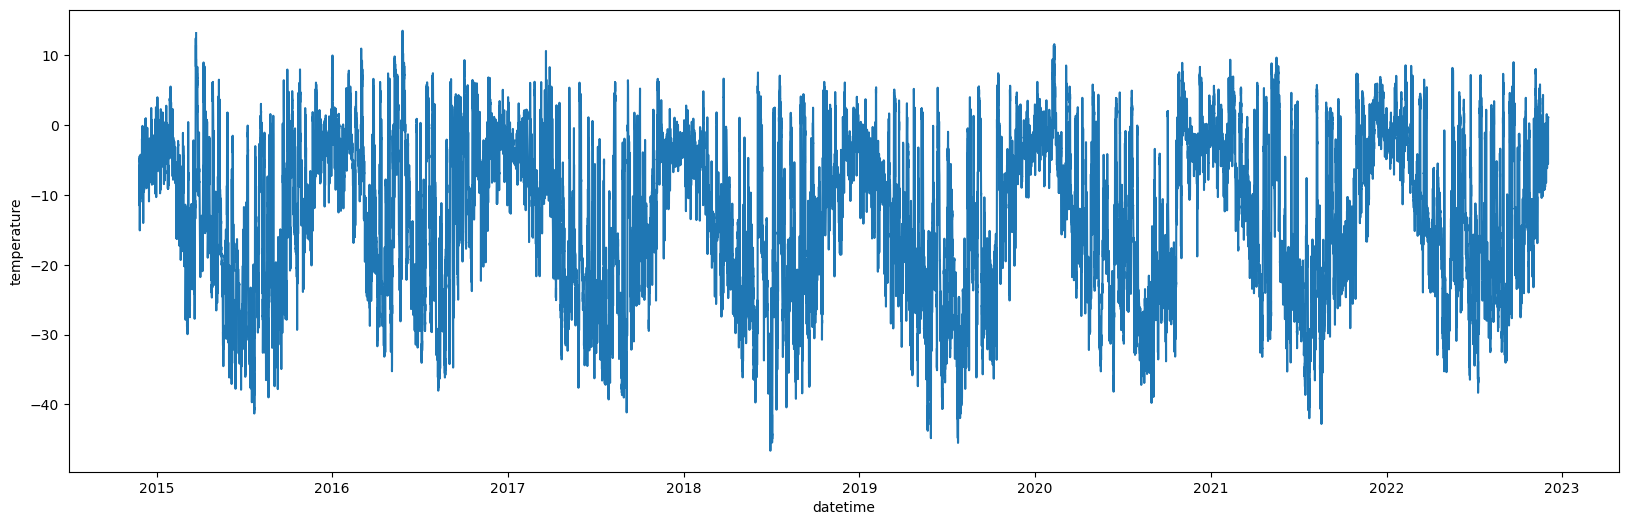

In [23]:
AWS_LC.temperature.plot(figsize=(20, 6))

## Compare to RACMO interpolated at the Larsen site

In [27]:
ds_wide = xr.open_dataset("../rcm/flask_wide_racmo2km.zarr", engine = 'zarr', chunks={})
ds_wide.load()

<xarray.Dataset> Size: 5GB
Dimensions:       (time: 17167, y: 111, x: 158)
Coordinates:
  * time          (time) datetime64[ns] 137kB 1979-01-01 ... 2025-12-31
  * x             (x) float32 632B -2.515e+06 -2.513e+06 ... -2.201e+06
  * y             (y) float32 444B 1.09e+06 1.092e+06 ... 1.308e+06 1.31e+06
Data variables:
    ff10mcorr     (time, y, x) float32 1GB nan nan nan nan ... 0.0 0.0 0.0 0.0
    precipcorr    (time, y, x) float32 1GB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    snowmeltcorr  (time, y, x) float32 1GB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    t2mcorr       (time, y, x) float32 1GB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
Attributes:
    CDI:          Climate Data Interface version 2.4.4 (https://mpimet.mpg.de...
    CDO:          Climate Data Operators version 2.4.4 (https://mpimet.mpg.de...
    Conventions:  CF-1.6
    grid:         Map Projection: Antarctic Polar Stereographic EPSG3031 - Ma...
    history:      Wed May 20 22:39:46 2026: cdo -f nc4 -z zip_5 copy ff10m/ff...
    institution:  IMAU (Brice Noel)
    netcdf:       4.9.0 of Jan  4 2023 16:53:07 $
    title:        Daily mean ff10m field at 2km (RACMO2.3p2 ANT27 ERA)

### AWS location

In [59]:
aws20_locations = gpd.read_file("../../data/flask/aws/larsen_AWS20_location.geojson")   # created by code/aws/larsen_AWS_fieldseason.ipynb
aws20_locations.to_crs(epsg=3031, inplace=True)
aws20_locations

,geometry
0,POINT (-2299145.99 1159921.946)


In [61]:
aws18_locations = gpd.read_file("../../data/flask/aws/larsen_AWS18_location.geojson")  # created by code/aws/larsen_AWS_fieldseason.ipynb
aws18_locations.to_crs(epsg=3031, inplace=True)

### Field site locations


In [73]:
field_site_locations = gpd.read_file("/Users/jkingslake/Documents/projects/current_projects/AntPen_NSF_NERC/fieldwork/recce_planning_oct25/site_names.shp")
field_site_locations.to_crs(epsg=3031, inplace=True)
flask_AWS_location = field_site_locations.iloc[[2]]
flask_AWS_location

,Site,Lat,Long,Elevation,geometry
2,Site 1,-65.793503,-62.677287,381,POINT (-2370653.103 1224775.687)


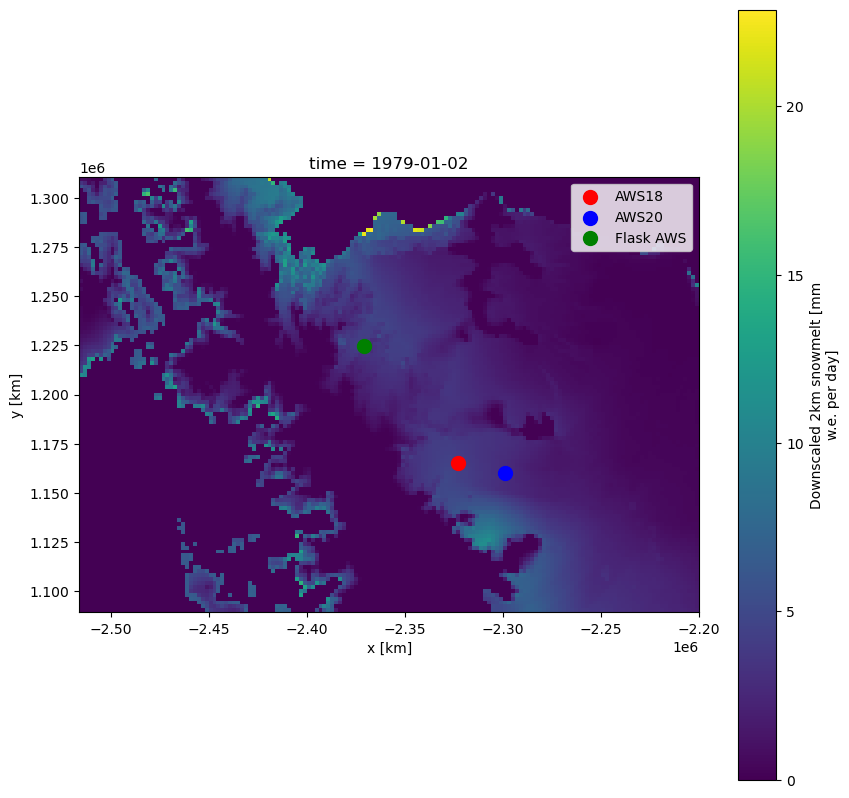

In [135]:
fig, ax = plt.subplots(figsize=(10, 10))
ds_wide.isel(time=1).snowmeltcorr.plot(ax=ax)
def add_dots(ax):
    aws18_locations.plot(ax=ax, label='AWS18', color='red', markersize=100)
    aws20_locations.plot(ax=ax, label='AWS20', color='blue', markersize=100)
    flask_AWS_location.plot(ax=ax, label='Flask AWS', color='green', markersize=100)
add_dots(ax)
plt.gca().set_aspect('equal') 
plt.legend()


In [99]:
racmo_at_aws18 = ds_wide.sel(x=aws18_locations.geometry.x.values[0], y=aws18_locations.geometry.y.values[0], method='nearest').t2mcorr - 273.15
racmo_at_aws18 = racmo_at_aws18.rename('AWS_18_t2m_racmo')
racmo_at_aws18.attrs['long_name'] = 'RACMO2km 2m air temperature at AWS18 location'
racmo_at_aws18.attrs['units'] = 'C'

racmo_at_aws20 = ds_wide.sel(x=aws20_locations.geometry.x.values[0], y=aws20_locations.geometry.y.values[0], method='nearest').t2mcorr - 273.15
racmo_at_aws20 = racmo_at_aws20.rename('AWS_20_t2m_racmo')
racmo_at_aws20.attrs['long_name'] = 'RACMO2km 2m air temperature at AWS20 location'
racmo_at_aws20.attrs['units'] = 'C'

racmo_at_flask_AWS = ds_wide.sel(x=flask_AWS_location.geometry.x.values[0], y=flask_AWS_location.geometry.y.values[0], method='nearest').t2mcorr - 273.15
racmo_at_flask_AWS = racmo_at_flask_AWS.rename('Flask_AWS_t2m_racmo')
racmo_at_flask_AWS.attrs['long_name'] = 'RACMO2km 2m air temperature at Flask AWS location'
racmo_at_flask_AWS.attrs['units'] = 'C'

## Compare RACMO to itself at the locations of the three AWS sites

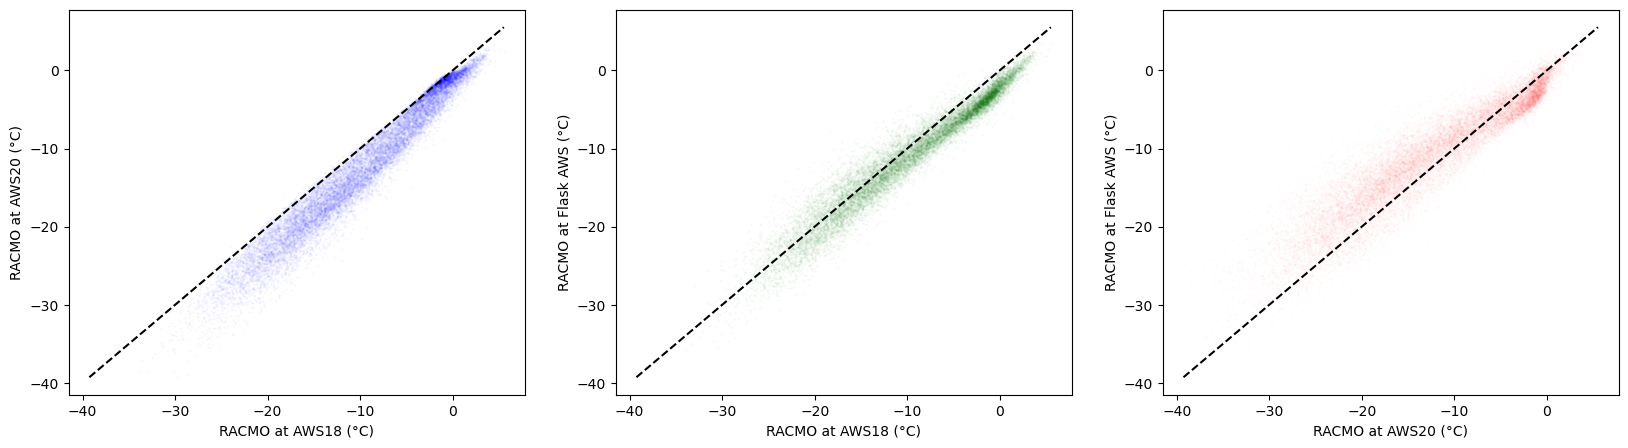

In [114]:
fig, axs = plt.subplots(1, 3, figsize=(20, 5))
axs[0].scatter(racmo_at_aws18, racmo_at_aws20, label='RACMO at AWS18 vs AWS20', color='blue', s=1, alpha=0.02)
axs[0].set_xlabel('RACMO at AWS18 (°C)')
axs[0].set_ylabel('RACMO at AWS20 (°C)')
min_temp = min(racmo_at_aws18.min().values, racmo_at_aws20.min().values)
max_temp = max(racmo_at_aws18.max().values, racmo_at_aws20.max().values)
axs[0].plot([min_temp, max_temp], [min_temp, max_temp], color='black', linestyle='--', label='1:1 line')

axs[1].scatter(racmo_at_aws18, racmo_at_flask_AWS, label='RACMO at AWS18 vs Flask AWS', color='green', s=1, alpha=0.02)
axs[1].set_xlabel('RACMO at AWS18 (°C)')
axs[1].set_ylabel('RACMO at Flask AWS (°C)')
axs[1].plot([min_temp, max_temp], [min_temp, max_temp], color='black', linestyle='--', label='1:1 line')

axs[2].scatter(racmo_at_aws20, racmo_at_flask_AWS, label='RACMO at AWS20 vs Flask AWS', color='red', s=1, alpha=0.01)
axs[2].set_xlabel('RACMO at AWS20 (°C)')
axs[2].set_ylabel('RACMO at Flask AWS (°C)')
axs[2].plot([min_temp, max_temp], [min_temp, max_temp], color='black', linestyle='--', label='1:1 line')

In [123]:
corr_18=xr.corr(racmo_at_aws18, ds_wide.t2mcorr, dim='time')
corr_20=xr.corr(racmo_at_aws20, ds_wide.t2mcorr, dim='time')
corr_flask=xr.corr(racmo_at_flask_AWS, ds_wide.t2mcorr, dim='time')

Text(0.5, 0.98, 'Spatial correlation of RACMO2km 2m, all year')

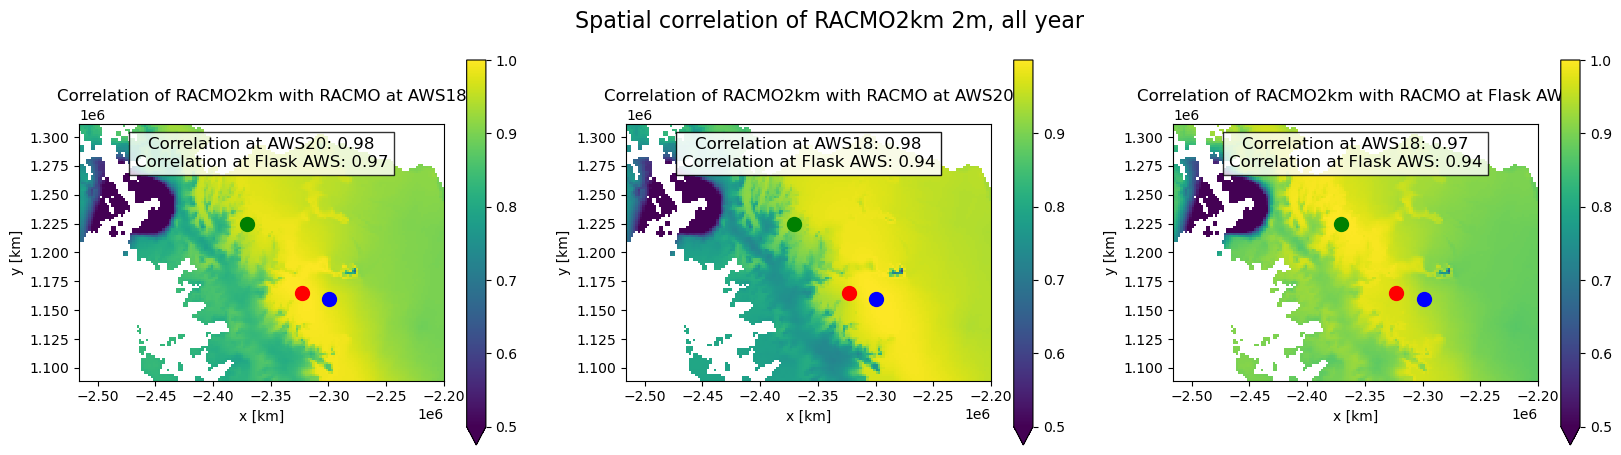

In [160]:
fig, axs = plt.subplots(1, 3, figsize=(20, 5))
corr_18.plot(ax=axs[0], vmin=0.5)
axs[0].set_title('Correlation of RACMO2km with RACMO at AWS18')
add_dots(axs[0])
corr_at_20 = corr_18.sel(x=aws20_locations.geometry.x.values[0], y=aws20_locations.geometry.y.values[0], method='nearest')
corr_at_flask = corr_18.sel(x=flask_AWS_location.geometry.x.values[0], y=flask_AWS_location.geometry.y.values[0], method='nearest')
axs[0].text(0.5, 0.95, f'Correlation at AWS20: {corr_at_20.values:.2f}\nCorrelation at Flask AWS: {corr_at_flask.values:.2f}', horizontalalignment='center', verticalalignment='top', transform=axs[0].transAxes, fontsize=12, bbox=dict(facecolor='white', alpha=0.8))

corr_20.plot(ax=axs[1], vmin=0.5)
axs[1].set_title('Correlation of RACMO2km with RACMO at AWS20')
add_dots(axs[1])
corr_at_18 = corr_20.sel(x=aws18_locations.geometry.x.values[0], y=aws18_locations.geometry.y.values[0], method='nearest')
corr_at_flask = corr_20.sel(x=flask_AWS_location.geometry.x.values[0], y=flask_AWS_location.geometry.y.values[0], method='nearest')
axs[1].text(0.5, 0.95, f'Correlation at AWS18: {corr_at_18.values:.2f}\nCorrelation at Flask AWS: {corr_at_flask.values:.2f}', horizontalalignment='center', verticalalignment='top', transform=axs[1].transAxes, fontsize=12, bbox=dict(facecolor='white', alpha=0.9))

corr_flask.plot(ax=axs[2], vmin=0.5)
axs[2].set_title('Correlation of RACMO2km with RACMO at Flask AWS')
add_dots(axs[2])
corr_at_18 = corr_flask.sel(x=aws18_locations.geometry.x.values[0], y=aws18_locations.geometry.y.values[0], method='nearest')
corr_at_20 = corr_flask.sel(x=aws20_locations.geometry.x.values[0], y=aws20_locations.geometry.y.values[0], method='nearest')
axs[2].text(0.5, 0.95, f'Correlation at AWS18: {corr_at_18.values:.2f}\nCorrelation at Flask AWS: {corr_at_20.values:.2f}', horizontalalignment='center', verticalalignment='top', transform=axs[2].transAxes, fontsize=12, bbox=dict(facecolor='white', alpha=0.8))

fig.suptitle('Spatial correlation of RACMO2km 2m, all year', fontsize=16)


In [ ]:
ds_wide_sum = ds_wide.where(ds_wide.time.dt.month.isin([11, 12, 1]), drop=True)


In [158]:
racmo_at_aws18_sum = ds_wide_sum.sel(x=aws18_locations.geometry.x.values[0], y=aws18_locations.geometry.y.values[0], method='nearest').t2mcorr - 273.15
racmo_at_aws20_sum = ds_wide_sum.sel(x=aws20_locations.geometry.x.values[0], y=aws20_locations.geometry.y.values[0], method='nearest').t2mcorr - 273.15
racmo_at_flask_sum = ds_wide_sum.sel(x=flask_AWS_location.geometry.x.values[0], y=flask_AWS_location.geometry.y.values[0], method='nearest').t2mcorr - 273.15

corr_18_sum=xr.corr(racmo_at_aws18_sum, ds_wide_sum.t2mcorr, dim='time')
corr_20_sum=xr.corr(racmo_at_aws20_sum, ds_wide_sum.t2mcorr, dim='time')
corr_flask_sum=xr.corr(racmo_at_flask_sum, ds_wide_sum.t2mcorr, dim='time')

Text(0.5, 0.98, 'Spatial correlation of RACMO2km 2m, just Nov, Dec, Jan')

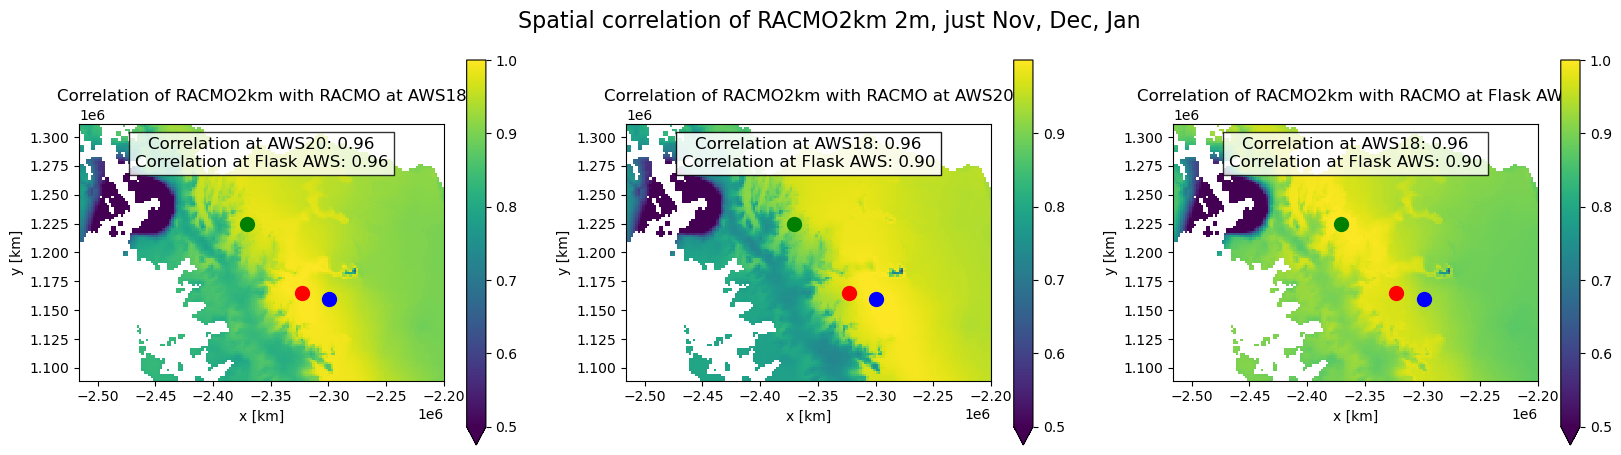

In [161]:
fig, axs = plt.subplots(1, 3, figsize=(20, 5))
corr_18.plot(ax=axs[0], vmin=0.5)
axs[0].set_title('Correlation of RACMO2km with RACMO at AWS18')
add_dots(axs[0])
corr_at_20 = corr_18_sum.sel(x=aws20_locations.geometry.x.values[0], y=aws20_locations.geometry.y.values[0], method='nearest')
corr_at_flask = corr_18_sum.sel(x=flask_AWS_location.geometry.x.values[0], y=flask_AWS_location.geometry.y.values[0], method='nearest')
axs[0].text(0.5, 0.95, f'Correlation at AWS20: {corr_at_20.values:.2f}\nCorrelation at Flask AWS: {corr_at_flask.values:.2f}', horizontalalignment='center', verticalalignment='top', transform=axs[0].transAxes, fontsize=12, bbox=dict(facecolor='white', alpha=0.8))

corr_20.plot(ax=axs[1], vmin=0.5)
axs[1].set_title('Correlation of RACMO2km with RACMO at AWS20')
add_dots(axs[1])
corr_at_18 = corr_20_sum.sel(x=aws18_locations.geometry.x.values[0], y=aws18_locations.geometry.y.values[0], method='nearest')
corr_at_flask = corr_20_sum.sel(x=flask_AWS_location.geometry.x.values[0], y=flask_AWS_location.geometry.y.values[0], method='nearest')
axs[1].text(0.5, 0.95, f'Correlation at AWS18: {corr_at_18.values:.2f}\nCorrelation at Flask AWS: {corr_at_flask.values:.2f}', horizontalalignment='center', verticalalignment='top', transform=axs[1].transAxes, fontsize=12, bbox=dict(facecolor='white', alpha=0.9))

corr_flask.plot(ax=axs[2], vmin=0.5)
axs[2].set_title('Correlation of RACMO2km with RACMO at Flask AWS')
add_dots(axs[2])
corr_at_18 = corr_flask_sum.sel(x=aws18_locations.geometry.x.values[0], y=aws18_locations.geometry.y.values[0], method='nearest')
corr_at_20 = corr_flask_sum.sel(x=aws20_locations.geometry.x.values[0], y=aws20_locations.geometry.y.values[0], method='nearest')
axs[2].text(0.5, 0.95, f'Correlation at AWS18: {corr_at_18.values:.2f}\nCorrelation at Flask AWS: {corr_at_20.values:.2f}', horizontalalignment='center', verticalalignment='top', transform=axs[2].transAxes, fontsize=12, bbox=dict(facecolor='white', alpha=0.8))

fig.suptitle('Spatial correlation of RACMO2km 2m, just Nov, Dec, Jan', fontsize=16)


## Compare RACMO and the AWS data

Text(0.5, 1.0, 'AWS18 vs RACMO2km 2m air temperature')

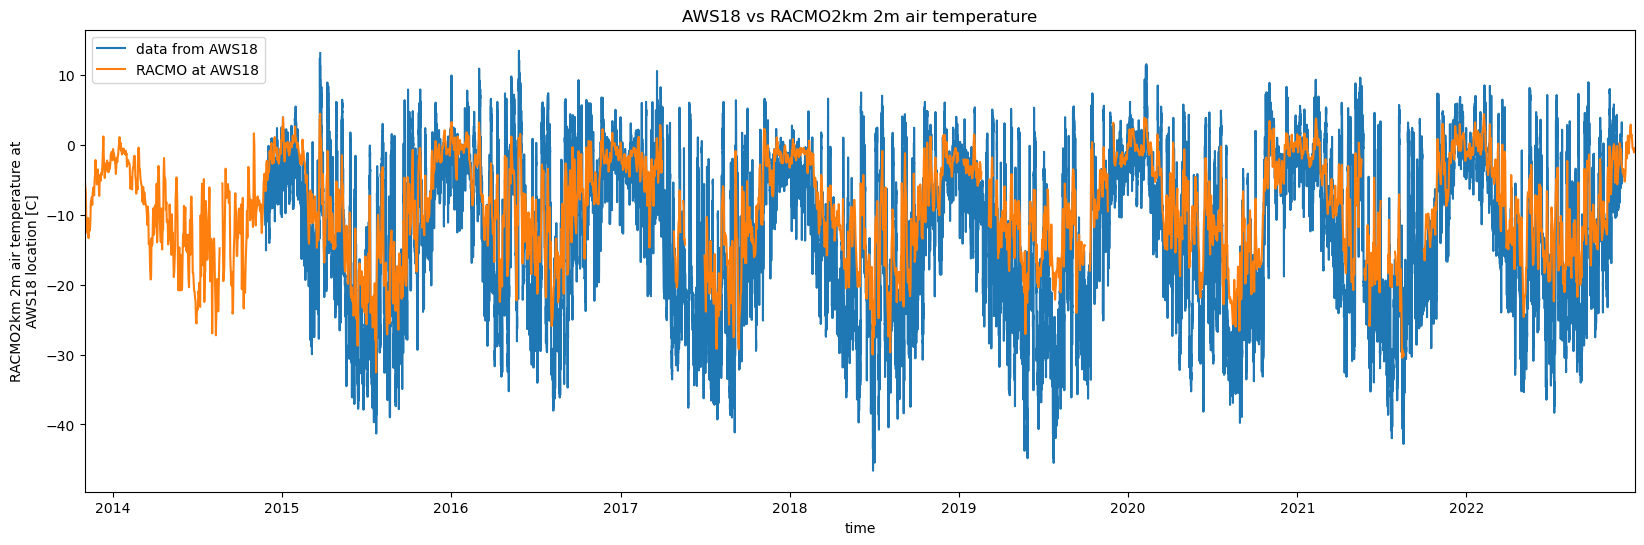

In [189]:
aws18_ds.plot(label='data from AWS18', figsize=(20, 6))
racmo_at_aws18.plot(xlim=(pd.Timestamp('2013-11-01'), pd.Timestamp('2022-12-31')),  label='RACMO at AWS18')
plt.legend()
plt.title('AWS18 vs RACMO2km 2m air temperature')

Text(0.5, 1.0, 'AWS20 vs RACMO2km 2m air temperature')

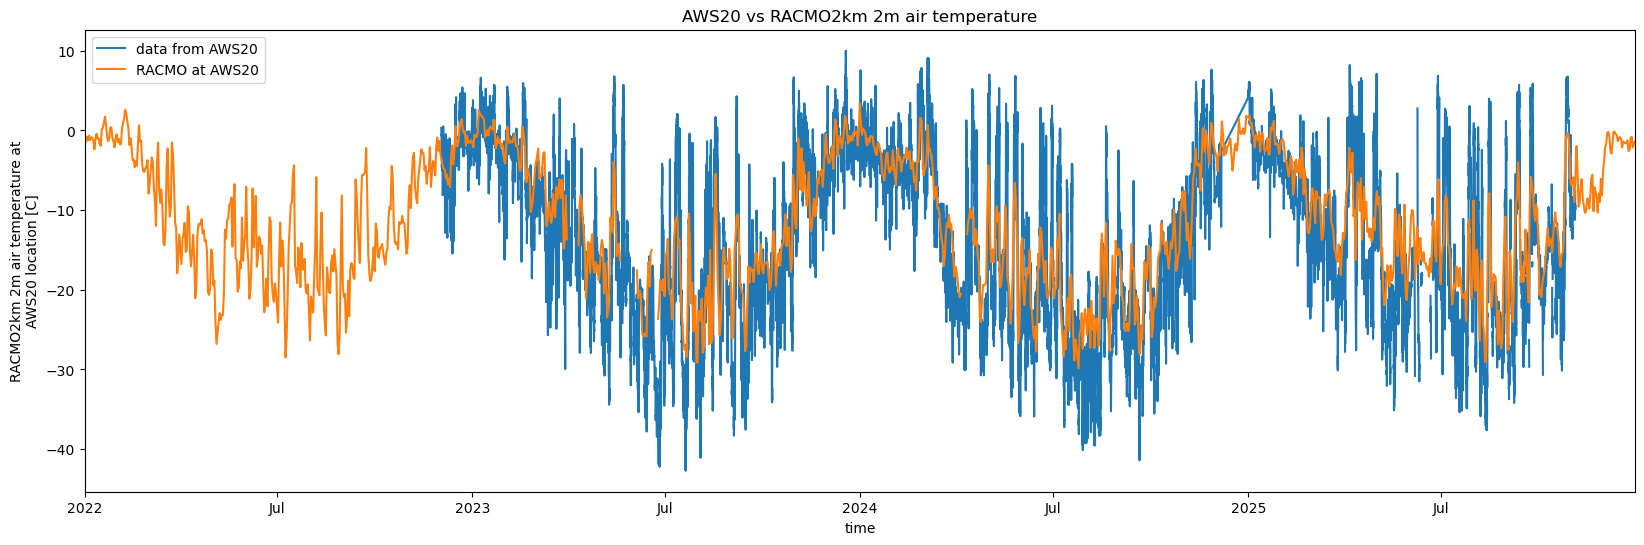

In [168]:
aws20_ds1.plot(label='data from AWS20', figsize=(20, 6))
racmo_at_aws20.plot(xlim=(pd.Timestamp('2022-01-01'), pd.Timestamp('2025-12-31')),  label='RACMO at AWS20')
plt.legend()
plt.title('AWS20 vs RACMO2km 2m air temperature')

Text(0.5, 1.0, 'Flask AWS vs RACMO2km 2m air temperature')

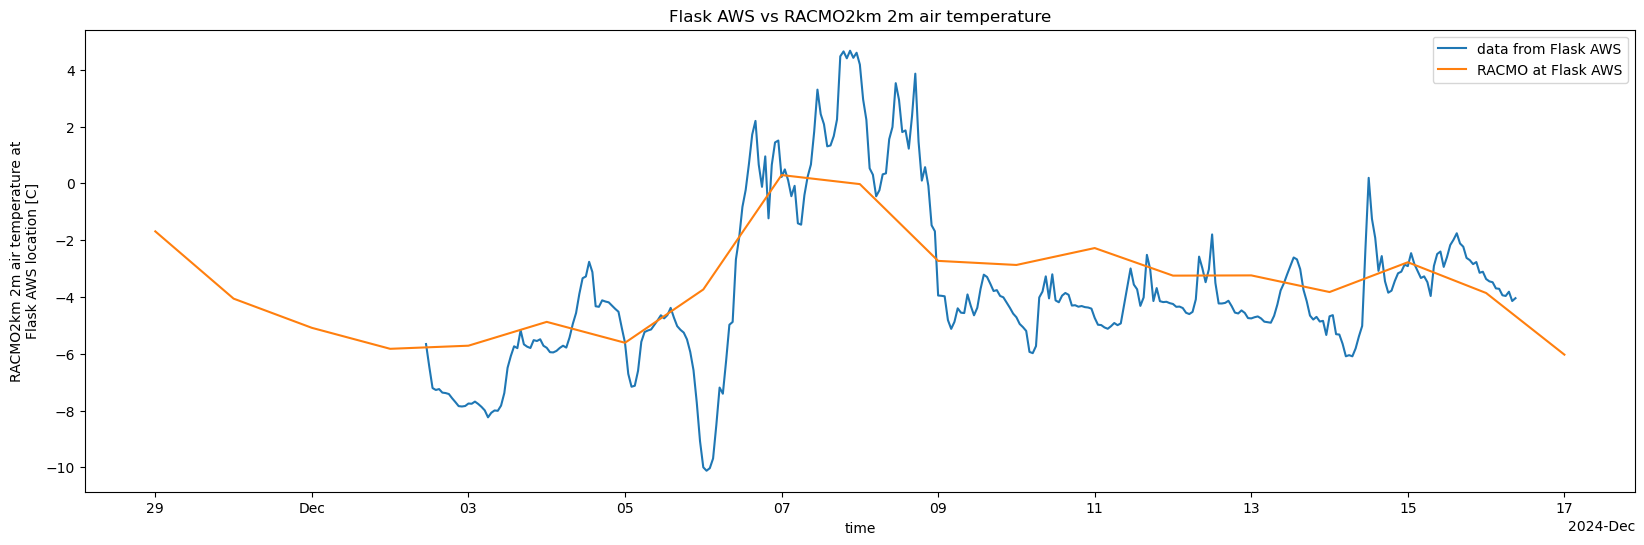

In [ ]:
FG_AWS = xr.load_dataset('aws_season_1.nc')
FG_AWS.TempVue20T_C_Avg.plot(label='data from Flask AWS', figsize=(20, 6))
racmo_at_flask_AWS.sel(time=slice(pd.Timestamp('2024-11-29'), pd.Timestamp('2024-12-17'))).plot(label='RACMO at Flask AWS')
plt.legend()
plt.title('Flask AWS vs RACMO2km 2m air temperature')

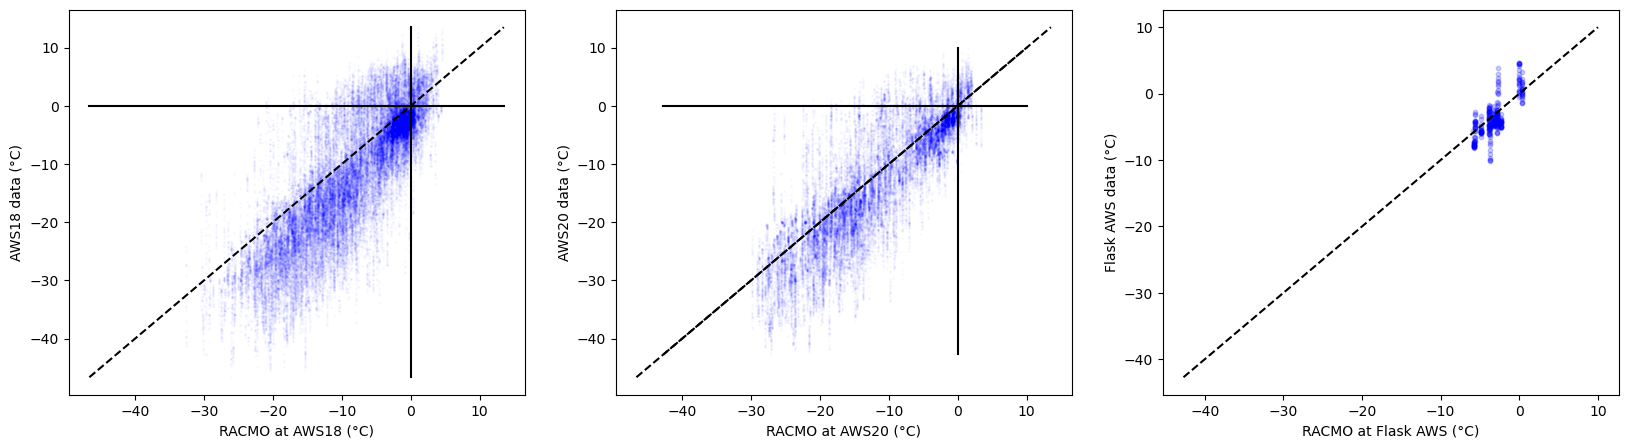

In [208]:
fig, axs = plt.subplots(1, 3, figsize=(20, 5))

racmo_at_aws18_time_intered = racmo_at_aws18.sel(time=aws18_ds.datetime, method='nearest')

axs[0].scatter(racmo_at_aws18_time_intered, 
               aws18_ds,  
               color='blue', s=1, alpha=0.02)
axs[0].set_xlabel('RACMO at AWS18 (°C)')
axs[0].set_ylabel('AWS18 data (°C)')

min_temp, max_temp = min(aws18_ds.min().values, aws18_ds.min().values), max(aws18_ds.max().values, aws18_ds.max().values)
axs[0].plot([min_temp, max_temp], [min_temp, max_temp], color='black', linestyle='--', label='1:1 line')
axs[0].plot([0, 0], [min_temp, max_temp], color='black', linestyle='-')
axs[0].plot([min_temp, max_temp], [0, 0], color='black', linestyle='-')

racmo_at_aws20_time_intered = racmo_at_aws20.sel(time=aws20_ds1.datetime, method='nearest')

axs[1].scatter(racmo_at_aws20_time_intered, 
               aws20_ds1, 
               color='blue', s=1, alpha=0.02)
axs[1].set_xlabel('RACMO at AWS20 (°C)')
axs[1].set_ylabel('AWS20 data (°C)')
axs[1].plot([min_temp, max_temp], [min_temp, max_temp], color='black', linestyle='--', label='1:1 line')

min_temp, max_temp = min(aws20_ds1.min().values, aws20_ds1.min().values), max(aws20_ds1.max().values, aws20_ds1.max().values)
axs[1].plot([min_temp, max_temp], [min_temp, max_temp], color='black', linestyle='--', label='1:1 line')
axs[1].plot([0, 0], [min_temp, max_temp], color='black', linestyle='-')
axs[1].plot([min_temp, max_temp], [0, 0], color='black', linestyle='-')

racmo_at_flask_AWS_time_intered = racmo_at_flask_AWS_time_intered = racmo_at_flask_AWS.sel(time=FG_AWS.TempVue20T_C_Avg.time, method='nearest')

axs[2].scatter(racmo_at_flask_AWS_time_intered, FG_AWS.TempVue20T_C_Avg, color='blue', s=10, alpha=0.2)
axs[2].set_xlabel('RACMO at Flask AWS (°C)')
axs[2].set_ylabel('Flask AWS data (°C)')
axs[2].plot([min_temp, max_temp], [min_temp, max_temp], color='black', linestyle='--', label='1:1 line')


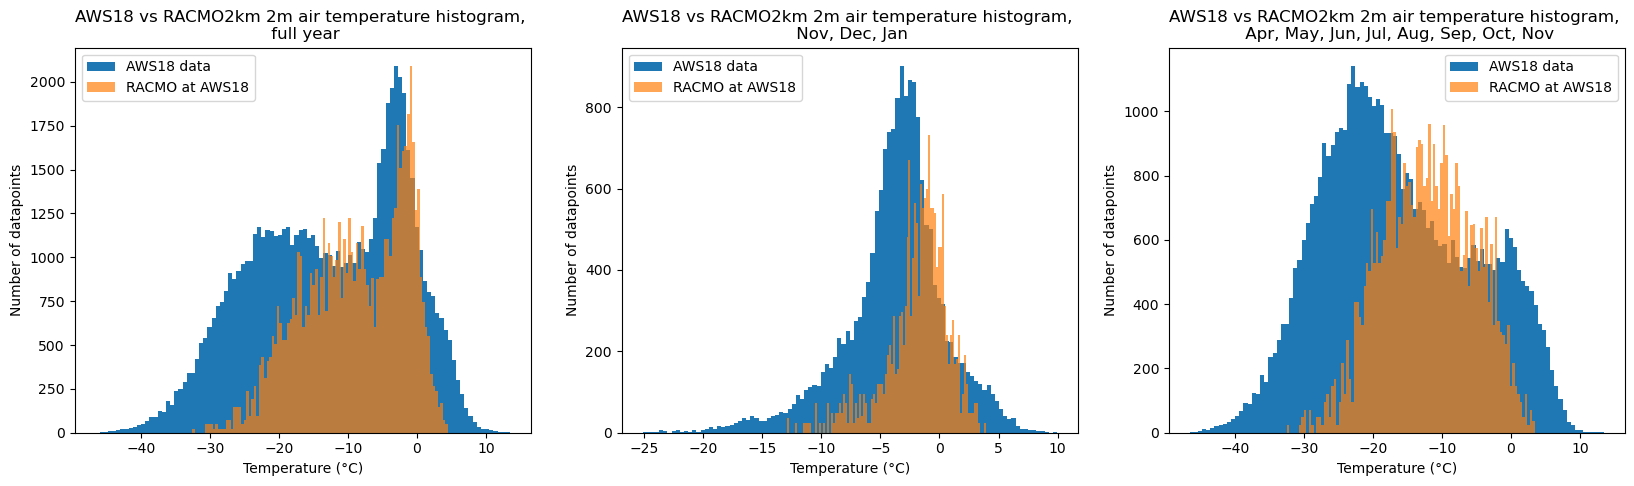

In [263]:
fig, axs = plt.subplots(1, 3, figsize=(20, 5))

aws18_ds.plot.hist(bins=100,  label='AWS18 data', ax=axs[0]);
racmo_at_aws18_time_intered.plot.hist( bins=100, alpha=0.7, label='RACMO at AWS18', ax=axs[0]);
axs[0].set_ylabel('Number of datapoints')
axs[0].set_xlabel('Temperature (°C)')
axs[0].set_title('AWS18 vs RACMO2km 2m air temperature histogram, \n full year')
axs[0].legend()


aws18_ds.where(aws18_ds.datetime.dt.month.isin([11, 12, 1]), drop=True).plot.hist(bins=100,  label='AWS18 data', ax=axs[1]);
racmo_at_aws18_time_intered.where(racmo_at_aws18_time_intered.datetime.dt.month.isin([11, 12, 1]), drop=True).plot.hist( bins=100, alpha=0.7, label='RACMO at AWS18', ax=axs[1]);
axs[1].set_ylabel('Number of datapoints')
axs[1].set_xlabel('Temperature (°C)')
axs[1].set_title('AWS18 vs RACMO2km 2m air temperature histogram, \n Nov, Dec, Jan')
axs[1].legend()

aws18_ds.where(aws18_ds.datetime.dt.month.isin([4, 5, 6, 7, 8, 9, 10, 11]), drop=True).plot.hist(bins=100,  label='AWS18 data', ax=axs[2]);
racmo_at_aws18_time_intered.where(racmo_at_aws18_time_intered.datetime.dt.month.isin([4, 5, 6, 7, 8, 9, 10, 11]), drop=True).plot.hist( bins=100, alpha=0.7, label='RACMO at AWS18', ax=axs[2]);
axs[2].set_ylabel('Number of datapoints')
axs[2].set_xlabel('Temperature (°C)')
axs[2].set_title('AWS18 vs RACMO2km 2m air temperature histogram, \n Apr, May, Jun, Jul, Aug, Sep, Oct, Nov')
axs[2].legend()

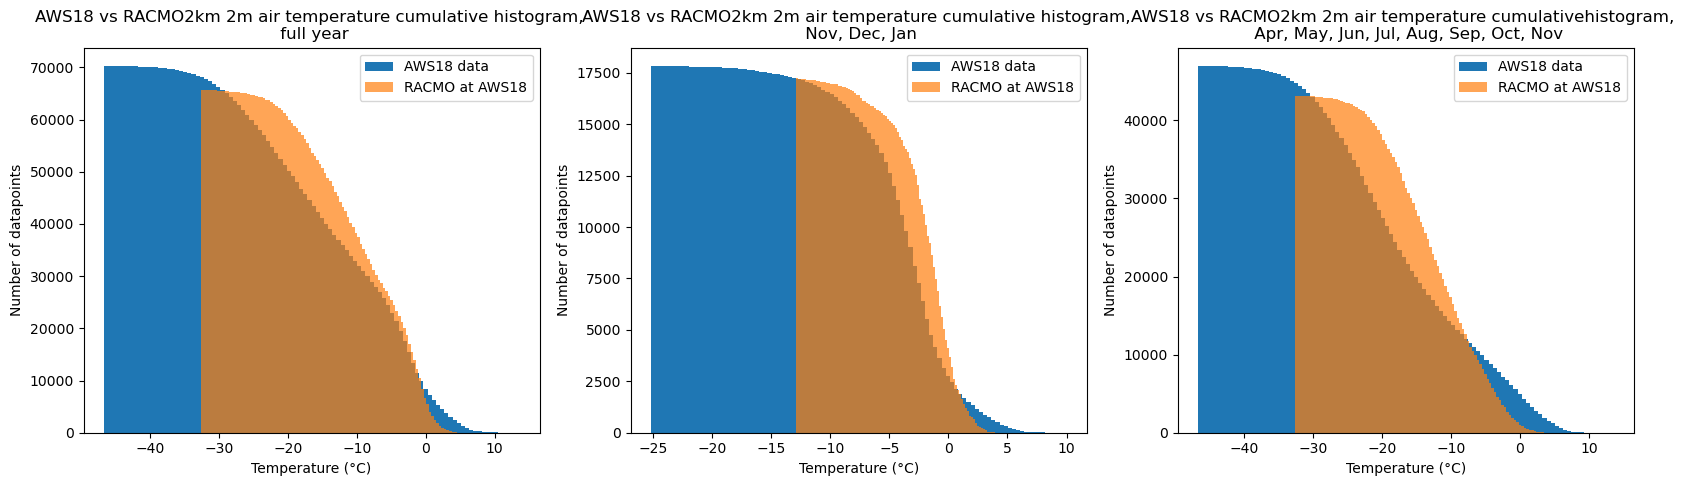

In [266]:
fig, axs = plt.subplots(1, 3, figsize=(20, 5))

aws18_ds.plot.hist(cumulative=-1, bins=100,  label='AWS18 data', ax=axs[0]);
racmo_at_aws18_time_intered.plot.hist(cumulative=-1, bins=100, alpha=0.7, label='RACMO at AWS18', ax=axs[0]);
axs[0].set_ylabel('Number of datapoints')
axs[0].set_xlabel('Temperature (°C)')
axs[0].set_title('AWS18 vs RACMO2km 2m air temperature cumulative histogram, \n full year')
axs[0].legend()


aws18_ds.where(aws18_ds.datetime.dt.month.isin([11, 12, 1]), drop=True).plot.hist(cumulative=-1, bins=100,  label='AWS18 data', ax=axs[1]);
racmo_at_aws18_time_intered.where(racmo_at_aws18_time_intered.datetime.dt.month.isin([11, 12, 1]), drop=True).plot.hist( cumulative=-1, bins=100, alpha=0.7, label='RACMO at AWS18', ax=axs[1]);
axs[1].set_ylabel('Number of datapoints')
axs[1].set_xlabel('Temperature (°C)')
axs[1].set_title('AWS18 vs RACMO2km 2m air temperature cumulative histogram, \n Nov, Dec, Jan')
axs[1].legend()

aws18_ds.where(aws18_ds.datetime.dt.month.isin([4, 5, 6, 7, 8, 9, 10, 11]), drop=True).plot.hist(cumulative=-1, bins=100,  label='AWS18 data', ax=axs[2]);
racmo_at_aws18_time_intered.where(racmo_at_aws18_time_intered.datetime.dt.month.isin([4, 5, 6, 7, 8, 9, 10, 11]), drop=True).plot.hist( cumulative=-1, bins=100, alpha=0.7, label='RACMO at AWS18', ax=axs[2]);
axs[2].set_ylabel('Number of datapoints')
axs[2].set_xlabel('Temperature (°C)')
axs[2].set_title('AWS18 vs RACMO2km 2m air temperature cumulativehistogram, \n Apr, May, Jun, Jul, Aug, Sep, Oct, Nov')
axs[2].legend()



Text(0, 0.5, 'Camp Tskin (K)')

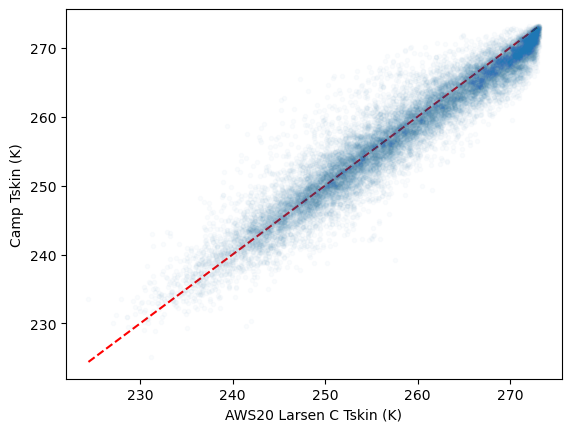

In [ ]:
x = tskin.tskin.sel( method='nearest', rlon=rlon_AWS20, rlat=rlat_AWS20)
y = tskin.tskin.sel( method='nearest', rlon=rlon_field_site[5], rlat=rlat_field_site[5])

plt.plot([x.min(), x.max()], [x.min(), x.max()], 'r--')
plt.plot(x, y, '.', alpha=0.02)
plt.xlabel('AWS20 Larsen C Tskin (K)')
plt.ylabel(f'{field_site_locations.Site.values[I]} Tskin (K)')
## add 1:1 line


Text(0.5, 1.0, 'Tskin comparison during Oct-Nov')

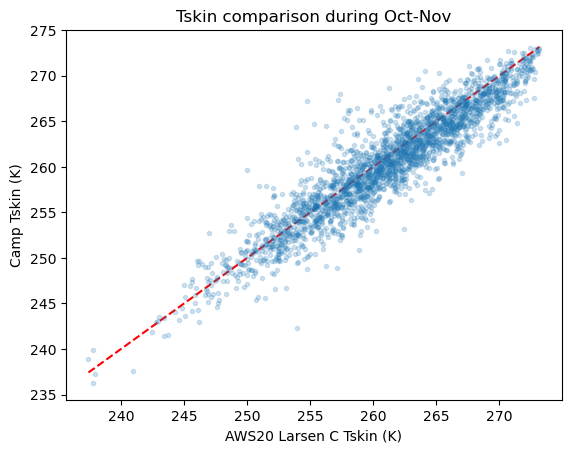

In [ ]:
tskin_ON = tskin.tskin.where(tskin.tskin.time.dt.month.isin([10, 11]), drop=True)



x = tskin_ON.sel( method='nearest', rlon=rlon_AWS20, rlat=rlat_AWS20)
y = tskin_ON.sel( method='nearest', rlon=rlon_field_site[5], rlat=rlat_field_site[5])

plt.plot([x.min(), x.max()], [x.min(), x.max()], 'r--')
plt.plot(x, y, '.', alpha=0.2)
plt.xlabel('AWS20 Larsen C Tskin (K)')
plt.ylabel(f'{field_site_locations.Site.values[I]} Tskin (K)')
plt.title('Tskin comparison during Oct-Nov')


<xarray.DataArray 'tskin' (height: 1, rlat: 294, rlon: 390)> Size: 459kB
dask.array<mean_agg-aggregate, shape=(1, 294, 390), dtype=float32, chunksize=(1, 100, 100), chunktype=numpy.ndarray>
Coordinates:
  * height   (height) float64 8B 0.0
    lat      (rlat, rlon) float64 917kB dask.array<chunksize=(100, 100), meta=np.ndarray>
    lon      (rlat, rlon) float64 917kB dask.array<chunksize=(100, 100), meta=np.ndarray>
  * rlat     (rlat) float64 2kB -8.7 -8.65 -8.6 -8.55 -8.5 ... 5.8 5.85 5.9 5.95
  * rlon     (rlon) float64 3kB -32.0 -31.95 -31.9 ... -12.65 -12.6 -12.55

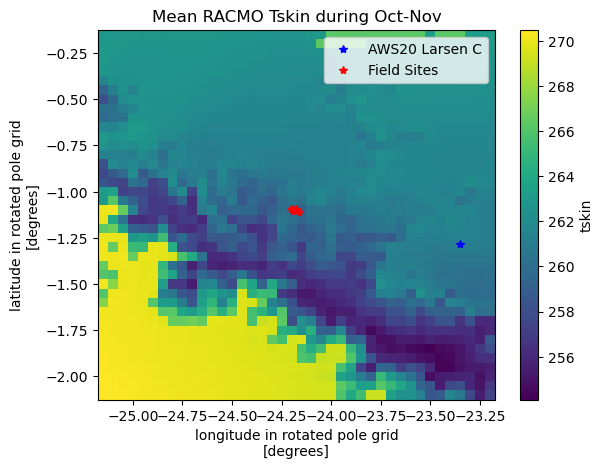

In [ ]:

d=1
tskin_ON_mean = tskin_ON.mean(dim='time')
tskin_ON_mean.sel(rlon = slice(rlon_field_site[0]-d, rlon_field_site[0]+d), rlat = slice(rlat_field_site[0]-d, rlat_field_site[0]+d)).plot()
plt.plot(rlon_AWS20, rlat_AWS20,'b*', label='AWS20 Larsen C')
plt.plot(rlon_field_site, rlat_field_site,'r*', label='Field Sites')
plt.legend()
plt.title('Mean RACMO Tskin during Oct-Nov')

tskin_ON_mean


In [ ]:
import statsmodels.formula.api as smf

df = pd.DataFrame({"x": x.squeeze().values, "y": y.squeeze().values})
df

,x,y
0,256.780457,255.061722
1,258.101227,258.601227
2,251.529114,252.033020
3,255.760284,257.619659
4,259.314301,262.935394
...,...,...
2435,263.880371,262.435059
2436,264.466278,263.431122
2437,262.432922,261.143860
2438,269.564758,269.900696


In [ ]:
model = smf.ols("y ~ x", data=df).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.863
Model:                            OLS   Adj. R-squared:                  0.863
Method:                 Least Squares   F-statistic:                 1.530e+04
Date:                Fri, 20 Mar 2026   Prob (F-statistic):               0.00
Time:                        12:06:52   Log-Likelihood:                -5399.2
No. Observations:                2440   AIC:                         1.080e+04
Df Residuals:                    2438   BIC:                         1.081e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     22.0813      1.927     11.459      0.0

In [ ]:
AWS_t = tskin.tskin.sel(method='nearest', rlon=rlon_AWS20, rlat=rlat_AWS20)
corr=xr.corr(AWS_t, tskin.tskin, dim='time').load()

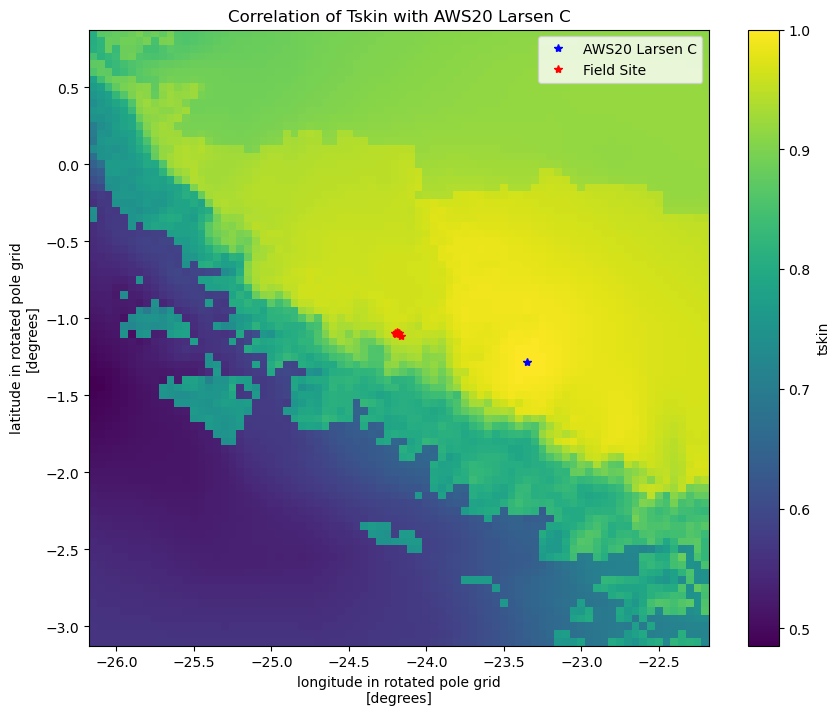

In [ ]:
d = 2
corr.sel(rlon = slice(rlon_field_site[0]-d, rlon_field_site[0]+d), rlat = slice(rlat_field_site[0]-d, rlat_field_site[0]+d)).plot(figsize=(10, 8))
plt.title('Correlation of Tskin with AWS20 Larsen C')
plt.plot(rlon_AWS20, rlat_AWS20,'b*', label='AWS20 Larsen C')
plt.plot(rlon_field_site, rlat_field_site,'r*', label='Field Site')
plt.legend()


In [ ]:
tskin_ON = tskin.tskin.where(tskin.tskin.time.dt.month.isin([10, 11]), drop=True)
AWS_t_ON = tskin_ON.sel(method='nearest', rlon=rlon_AWS20, rlat=rlat_AWS20)
corr=xr.corr(AWS_t_ON, tskin_ON, dim='time').load()

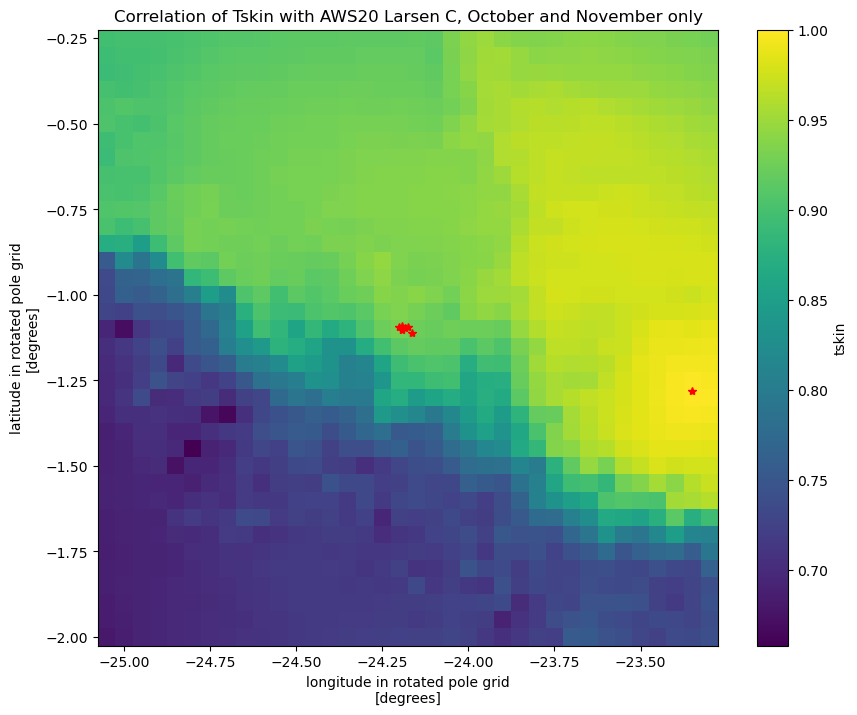

In [ ]:
d = 0.9
corr.sel(rlon = slice(rlon_field_site[0]-d, rlon_field_site[0]+d), rlat = slice(rlat_field_site[0]-d, rlat_field_site[0]+d)).plot(figsize=(10, 8))
plt.title('Correlation of Tskin with AWS20 Larsen C, October and November only')
plt.plot(rlon_AWS20, rlat_AWS20,'r*')
plt.plot(rlon_field_site, rlat_field_site,'r*')

In [ ]:
def corr_with_AWS(fld_chunk):
    # fld_chunk is one year's worth of data
    aws_chunk = AWS_t.sel(time=fld_chunk.time)   # align to same times
    return xr.corr(aws_chunk, fld_chunk, dim="time")

corr_yearly = tskin.tskin.groupby("time.year").map(corr_with_AWS).load()

In [ ]:
corr_yearly#.hvplot.image(x="rlon", y="rlat")

<xarray.DataArray 'tskin' (year: 41, height: 1, rlat: 294, rlon: 390)> Size: 19MB
array([[[[0.62194943, 0.6236972 , 0.62566143, ..., 0.6325134 ,
          0.631352  , 0.63104177],
         [0.6208986 , 0.62275535, 0.6247725 , ..., 0.6338176 ,
          0.6324102 , 0.6319836 ],
         [0.6202047 , 0.62219584, 0.62368995, ..., 0.63427114,
          0.6338344 , 0.6319072 ],
         ...,
         [0.53837657, 0.5405157 , 0.54235214, ..., 0.7517018 ,
          0.75189984, 0.7516438 ],
         [0.5377648 , 0.53998065, 0.5417943 , ..., 0.7516861 ,
          0.7514426 , 0.7509436 ],
         [0.53734815, 0.53934246, 0.5410702 , ..., 0.75087494,
          0.7510273 , 0.7505685 ]]],


       [[[0.51888406, 0.52149826, 0.5231536 , ..., 0.6343635 ,
          0.6370079 , 0.6323058 ],
         [0.5172551 , 0.5194961 , 0.5211531 , ..., 0.6416331 ,
          0.6393242 , 0.6360012 ],
         [0.5150796 , 0.5170058 , 0.51916677, ..., 0.6406855 ,
...
         [0.407246  , 0.41048494, 0.41378984, ..., 0.66009974,
          0.66037834, 0.6613723 ],
         [0.40839416, 0.41184244, 0.41509822, ..., 0.6594926 ,
          0.66021055, 0.6613189 ]]],


       [[[0.66353494, 0.6631934 , 0.6640422 , ..., 0.4148413 ,
          0.42017907, 0.41166493],
         [0.6665836 , 0.66759664, 0.6672286 , ..., 0.42380524,
          0.4225659 , 0.41856626],
         [0.6705943 , 0.67150337, 0.6718977 , ..., 0.42172977,
          0.4121725 , 0.413875  ],
         ...,
         [0.69995177, 0.7001221 , 0.7005124 , ..., 0.7070702 ,
          0.7088555 , 0.7102732 ],
         [0.7002038 , 0.7005703 , 0.70097643, ..., 0.70868134,
          0.70967305, 0.71079385],
         [0.70077837, 0.701042  , 0.7014856 , ..., 0.7090221 ,
          0.7108617 , 0.71204925]]]],
      shape=(41, 1, 294, 390), dtype=float32)
Coordinates:
  * height   (height) float64 8B 0.0
  * rlat     (rlat) float64 2kB -8.7 -8.65 -8.6 -8.55 -8.5 ... 5.8 5.85 5.9 5.95
  * rlon     (rlon) float64 3kB -32.0 -31.95 -31.9 ... -12.65 -12.6 -12.55
  * year     (year) int64 328B 1979 1980 1981 1982 1983 ... 2016 2017 2018 2019

In [ ]:
import ipywidgets as widgets
import matplotlib.pyplot as plt

@widgets.interact(idx=(0, corr_yearly.year.size - 1))
def plot_frame(idx=0):
    plt.figure(figsize=(6,5))
    corr_yearly.isel(year=idx).plot(vmin=0, vmax=1  )
    plt.title(str(corr_yearly.year.values[idx]))
    plt.plot(rlon_AWS20, rlat_AWS20,'r*')
    plt.plot(rlon_field_site, rlat_field_site,'r*')
    plt.show()

interactive(children=(IntSlider(value=0, description='idx', max=40), Output()), _dom_classes=('widget-interact…

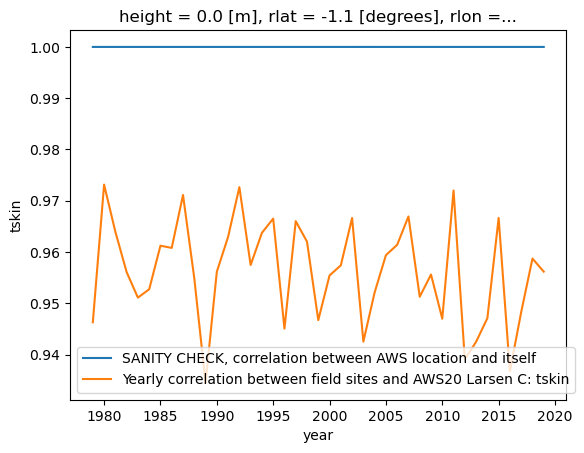

In [ ]:
corr_yearly.sel( method='nearest', rlon=rlon_AWS20, rlat=rlat_AWS20).plot(label='SANITY CHECK, correlation between AWS location and itself')
corr_yearly.sel( method='nearest', rlon=rlon_field_site[5], rlat=rlat_field_site[5]).plot(label='Yearly correlation between field sites and AWS20 Larsen C: tskin')
plt.legend()

In [ ]:
d=0.5
AWS_t = tskin.tskin.sel(method='nearest', rlon=rlon_AWS20, rlat=rlat_AWS20)
field = tskin.tskin.sel(rlon = slice(rlon_field_site[0]-d, rlon_field_site[0]+d), rlat = slice(rlat_field_site[0]-d, rlat_field_site[0]+d))

W = 365  # example: 365-day window; use whatever makes sense (e.g. 30, 90, etc.)

aws_roll = (
    AWS_t
    .rolling(time=W, center=True, min_periods=W)
    .construct("window")
)

field_roll = (
    field
    .rolling(time=W, center=True, min_periods=W)
    .construct("window")
)

# Rolling correlation: correlate over "window"
corr_roll = xr.corr(aws_roll, field_roll, dim="window").compute()
corr_roll

<xarray.DataArray 'tskin' (time: 14853, height: 1, rlat: 20, rlon: 20)> Size: 24MB
array([[[[0.853149  , 0.8556717 , 0.83443224, ..., 0.83631545,
          0.85647786, 0.86154425],
         [0.85552585, 0.85917526, 0.8539276 , ..., 0.8348366 ,
          0.8711006 , 0.9056338 ],
         [0.8634856 , 0.86500967, 0.83892554, ..., 0.8343127 ,
          0.8946014 , 0.9303834 ],
         ...,
         [0.96340615, 0.9622999 , 0.9651466 , ..., 0.9835297 ,
          0.98713756, 0.9875539 ],
         [0.95932424, 0.95841146, 0.95869774, ..., 0.98413867,
          0.98531914, 0.9857079 ],
         [0.9569251 , 0.9560302 , 0.9570203 , ..., 0.98068863,
          0.9866254 , 0.9843342 ]]],


       [[[0.8501762 , 0.8525593 , 0.83093804, ..., 0.8331995 ,
          0.85280955, 0.85794806],
         [0.8526154 , 0.8560542 , 0.85046124, ..., 0.8317857 ,
          0.8674782 , 0.90283674],
         [0.86073667, 0.86190575, 0.83550847, ..., 0.83133876,
...
         [0.9126268 , 0.9136177 , 0.9170273 , ..., 0.9748025 ,
          0.97459155, 0.9626633 ],
         [0.91175455, 0.91337055, 0.9177316 , ..., 0.96909845,
          0.9747948 , 0.9659787 ]]],


       [[[0.7149198 , 0.6686485 , 0.73090786, ..., 0.810641  ,
          0.821361  , 0.8199274 ],
         [0.71146625, 0.653621  , 0.72453535, ..., 0.78801864,
          0.8087729 , 0.86569715],
         [0.7064032 , 0.6734626 , 0.7350333 , ..., 0.79660577,
          0.83243096, 0.8829111 ],
         ...,
         [0.9135668 , 0.912981  , 0.9182382 , ..., 0.9724736 ,
          0.98132855, 0.98030293],
         [0.9135383 , 0.91439605, 0.9176506 , ..., 0.9745426 ,
          0.9743385 , 0.9627354 ],
         [0.91236085, 0.9138696 , 0.91810197, ..., 0.9687926 ,
          0.97461516, 0.9662326 ]]]],
      shape=(14853, 1, 20, 20), dtype=float32)
Coordinates:
  * height   (height) float64 8B 0.0
  * rlat     (rlat) float64 160B -1.6 -1.55 -1.5 -1.45 ... -0.8 -0.75 -0.7 -0.65
  * rlon     (rlon) float64 160B -24.65 -24.6 -24.55 ... -23.8 -23.75 -23.7
  * time     (time) datetime64[ns] 119kB 1979-01-01 1979-01-02 ... 2019-08-31

In [ ]:
@widgets.interact(idx=(0, corr_roll.time.size - 1))
def plot_frame(idx=0):
    plt.figure(figsize=(6,5))
    corr_roll.isel(time=idx).plot(vmin=0, vmax=1  )
    plt.title(str(corr_roll.time.values[idx]))
    plt.plot(rlon_AWS20, rlat_AWS20,'r*')
    plt.plot(rlon_field_site, rlat_field_site,'r*')
    plt.show()


# corr_roll.isel(time=1000).plot()
# plt.plot(rlon_AWS, rlat_AWS,'r*')
# plt.plot(rlon_field_site, rlat_field_site,'r*')

interactive(children=(IntSlider(value=0, description='idx', max=14852), Output()), _dom_classes=('widget-inter…

Text(0.5, 1.0, 'correlation at field site computed over a 1-year rolling window')

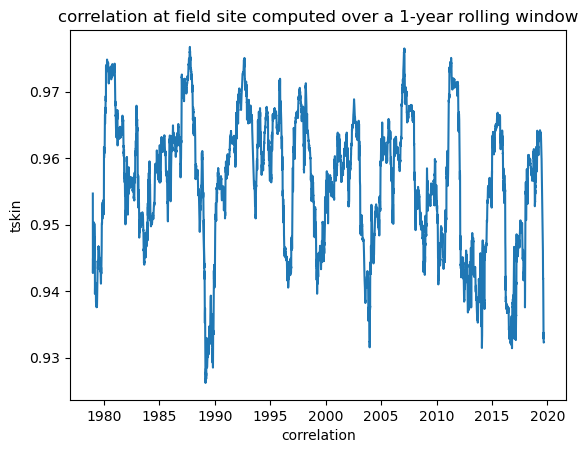

In [ ]:
corr_roll.sel( method='nearest', rlon=rlon_field_site[5], rlat=rlat_field_site[5]).plot(label='Yearly correlation between field sites and AWS20 Larsen C: tskin')
plt.xlabel('correlation')
plt.title('correlation at field site computed over a 1-year rolling window')

## Compare to our AWS on FG

In [ ]:
FG_AWS = xr.load_dataset('aws_season_1.nc')


In [ ]:
aws20_ds1

<xarray.DataArray 'temperature' (datetime: 42656)> Size: 341kB
array([ 3.09e-01, -1.49e-01, -9.00e-03, ..., -9.17e+00, -9.89e+00,
       -9.49e+00], shape=(42656,))
Coordinates:
  * datetime  (datetime) datetime64[ns] 341kB 2022-12-02T17:30:00 ... 2025-11...

Text(0.5, 1.0, 'Comparison of our Flask-Glacier AWS and Larsen C AWS, Late 2024')

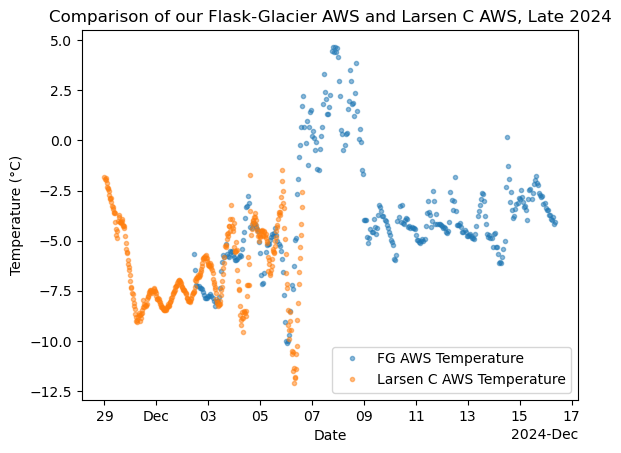

In [ ]:
FG_AWS.TempVue20T_C_Avg.plot( linestyle=' ', marker='.', alpha = 0.5, label ='FG AWS Temperature')
year = 2024
aws20_ds1.sel(datetime=slice(pd.Timestamp(f'{year}-11-29'), pd.Timestamp(f'{year}-12-31'))).plot( linestyle=' ', marker='.', alpha = 0.5, label ='Larsen C AWS Temperature')
plt.legend()
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.title('Comparison of our Flask-Glacier AWS and Larsen C AWS, Late 2024')
# ax[1].set_ylabel('Temperature (°C)')
# ax[1].set_xlabel('Date')

# ax[1].set_title(f'Larsen AWS Temperature, {year}')
# ax[1].grid()


# add_times('2024-11-25', -40, 'Field guides reach FG', ax[1])
# add_times('2024-11-30', -34, 'Science team reach FG', ax[1])
# add_times('2024-12-07', -28, 'End of fieldwork', ax[1]  )